## Step 1 - Packages

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt
from importlib import reload
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Step 2 - MNIST Data

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

x_train = x_train.reshape(-1,28,28,1)
x_test  = x_test.reshape(-1,28,28,1)

print("x_train : ",x_train.shape)
print("y_train : ",y_train.shape)
print("x_test  : ",x_test.shape)
print("y_test  : ",y_test.shape)

x_train :  (60000, 28, 28, 1)
y_train :  (60000,)
x_test  :  (10000, 28, 28, 1)
y_test  :  (10000,)


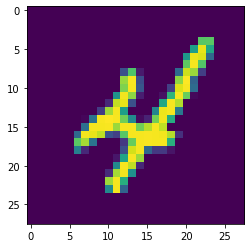

In [3]:
plt.imshow(x_train[9])

In [4]:
y_train[9]

4

## Step 3 - Preparing the data

In [5]:
print('Before normalization : Min={}, max={}'.format(x_train.min(),x_train.max()))

xmax=x_train.max()
x_train = x_train / xmax
x_test  = x_test  / xmax

print('After normalization  : Min={}, max={}'.format(x_train.min(),x_train.max()))

Before normalization : Min=0, max=255
After normalization  : Min=0.0, max=1.0


## Step 4 - Create model

In [6]:
model = keras.models.Sequential()

model.add( keras.layers.Input((28,28,1)) )

model.add( keras.layers.Conv2D(8, (3,3),  activation='relu') )
model.add( keras.layers.MaxPooling2D((2,2)))
model.add( keras.layers.Dropout(0.2))

model.add( keras.layers.Conv2D(16, (3,3), activation='relu') )
model.add( keras.layers.MaxPooling2D((2,2)))
model.add( keras.layers.Dropout(0.2))

model.add( keras.layers.Flatten()) 
model.add( keras.layers.Dense(100, activation='relu'))
model.add( keras.layers.Dropout(0.5))

model.add( keras.layers.Dense(10, activation='softmax'))

In [7]:
model.summary()

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 26, 26, 8)         80        
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 13, 13, 8)         0         
_________________________________________________________________
dropout (Dropout)            (None, 13, 13, 8)         0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 11, 11, 16)        1168      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 5, 5, 16)          0         
_________________________________________________________________
dropout_1 (Dropout)          (None, 5, 5, 16)          0         
_________________________________________________________________
flatten (Flatten)            (None, 400)               0

## Step 5 - Train the model

In [8]:
batch_size  = 512
epochs      =  16

history = model.fit(  x_train, y_train,
                      batch_size      = batch_size,
                      epochs          = epochs,
                      verbose         = 1,
                      validation_data = (x_test, y_test))

Epoch 1/16
118/118 [==============================] - 8s 65ms/step - loss: 1.6149 - accuracy: 0.4497 - val_loss: 0.3063 - val_accuracy: 0.9198
Epoch 2/16
118/118 [==============================] - 7s 56ms/step - loss: 0.4671 - accuracy: 0.8548 - val_loss: 0.1749 - val_accuracy: 0.9497
Epoch 3/16
118/118 [==============================] - 7s 59ms/step - loss: 0.3156 - accuracy: 0.9034 - val_loss: 0.1291 - val_accuracy: 0.9621
Epoch 4/16
118/118 [==============================] - 7s 59ms/step - loss: 0.2602 - accuracy: 0.9207 - val_loss: 0.1060 - val_accuracy: 0.9672
Epoch 5/16
118/118 [==============================] - 7s 62ms/step - loss: 0.2202 - accuracy: 0.9322 - val_loss: 0.0912 - val_accuracy: 0.9715
Epoch 6/16
118/118 [==============================] - 7s 61ms/step - loss: 0.1972 - accuracy: 0.9408 - val_loss: 0.0799 - val_accuracy: 0.9754
Epoch 7/16
118/118 [==============================] - 7s 62ms/step - loss: 0.1765 - accuracy: 0.9449 - val_loss: 0.0700 - val_accuracy: 0.9783

## Step 6 - Evaluate

In [9]:
score = model.evaluate(x_test, y_test, verbose=0)

print(f'Test loss     : {score[0]:4.4f}')
print(f'Test accuracy : {score[1]:4.4f}')

Test loss     : 0.0410
Test accuracy : 0.9868


In [10]:
y_softmax = model.predict(x_test)
y_pred    = np.argmax(y_softmax, axis=-1)

In [11]:
errors=[ i for i in range(len(x_test)) if y_pred[i]!=y_test[i] ]

In [12]:
len(errors)

132

In [13]:
print(confusion_matrix(y_test, y_pred)) # order matters! (actual, predicted)

[[ 976    1    0    0    0    0    1    1    1    0]
 [   0 1128    3    0    0    1    2    1    0    0]
 [   1    1 1024    2    0    1    0    2    1    0]
 [   0    0    0  999    0    3    0    5    3    0]
 [   0    0    0    0  969    0    2    1    2    8]
 [   1    0    0    4    0  884    2    1    0    0]
 [   6    2    0    0    1    4  944    0    1    0]
 [   0    2    8    1    0    0    0 1010    3    4]
 [   4    1    3    2    1    3    0    3  952    5]
 [   1    6    0    3    4    5    0    6    2  982]]


In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.99      0.99      1032
           3       0.99      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.98      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.99      0.98      0.98       974
           9       0.98      0.97      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000

